In [3]:
import pandas as pd
data = pd.read_csv('imputed_data.csv')
head = data.head()
head

,loan_amnt,verification_status,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,debt_settlement_flag,...,last_pymnt_d,out_prncp,out_prncp_inv,pub_rec,purpose,revol_util,term,total_acc,loan_paid,has_imputed_values
0,8000,Source Verified,0.0,0.0,148879.0,41401.0,25300.0,33679.0,Cash,N,...,May-2018,0.0,0.0,0.0,credit_card,55.1,36 months,24.0,1,0
1,12750,Verified,0.0,0.0,104074.0,79717.0,0.0,98374.0,Cash,N,...,Mar-2018,0.0,0.0,0.0,debt_consolidation,64.9,36 months,27.0,1,0
2,12000,Source Verified,0.0,0.0,23930.0,16536.0,8800.0,14130.0,Cash,N,...,Nov-2016,0.0,0.0,0.0,debt_consolidation,81.2,36 months,13.0,0,0
3,20000,Verified,0.0,0.0,15800.0,11510.0,8700.0,0.0,Cash,N,...,Nov-2015,0.0,0.0,0.0,debt_consolidation,72.8,60 months,18.0,1,0
4,30000,Not Verified,1.0,0.0,54683.0,26857.0,7500.0,44583.0,Cash,N,...,Jan-2018,0.0,0.0,1.0,debt_consolidation,67.9,60 months,13.0,0,0


In [3]:
data.isnull().sum()

loan_amnt                     0
verification_status           0
pub_rec_bankruptcies          0
tax_liens                     0
tot_hi_cred_lim               0
total_bal_ex_mort             0
total_bc_limit                0
total_il_high_credit_limit    0
disbursement_method           0
debt_settlement_flag          0
annual_inc                    0
collections_12_mths_ex_med    0
delinq_2yrs                   0
dti                           0
grade                         0
earliest_cr_line              0
emp_length                    0
home_ownership                0
inq_last_6mths                0
installment                   0
int_rate                      0
last_pymnt_d                  0
out_prncp                     0
out_prncp_inv                 0
pub_rec                       0
purpose                       0
revol_util                    0
term                          0
total_acc                     0
loan_paid                     0
has_imputed_values            0
monthly_

In [4]:
# get monthly income

data["monthly_income"] = data.annual_inc/12
data[["monthly_income", "annual_inc"]]


,monthly_income,annual_inc
0,14166.666667,170000.0
1,6250.000000,75000.0
2,5000.000000,60000.0
3,4000.000000,48000.0
4,2083.333333,25000.0
...,...,...
209995,9688.500000,116262.0
209996,16666.666667,200000.0
209997,6378.000000,76536.0
209998,11583.333333,139000.0


In [5]:
data["grade"].unique()
data["grade"].value_counts()


grade
C    62274
B    53490
D    37533
A    27056
E    19991
F     7421
G     2235
Name: count, dtype: int64

                            loan_amnt  pub_rec_bankruptcies  tax_liens  \
loan_amnt                    1.000000             -0.087828   0.013880   
pub_rec_bankruptcies        -0.087828              1.000000   0.028926   
tax_liens                    0.013880              0.028926   1.000000   
tot_hi_cred_lim              0.319905             -0.096375   0.003493   
total_bal_ex_mort            0.275344             -0.070200  -0.000021   
total_bc_limit               0.353632             -0.142241  -0.020503   
total_il_high_credit_limit   0.210108             -0.029184   0.010003   
annual_inc                   0.292406             -0.041358   0.036703   
collections_12_mths_ex_med  -0.017780              0.002384   0.009721   
delinq_2yrs                  0.004273             -0.047275   0.013179   
dti                          0.028158             -0.008978  -0.022946   
inq_last_6mths              -0.009049              0.073411   0.011143   
installment                  0.949002 

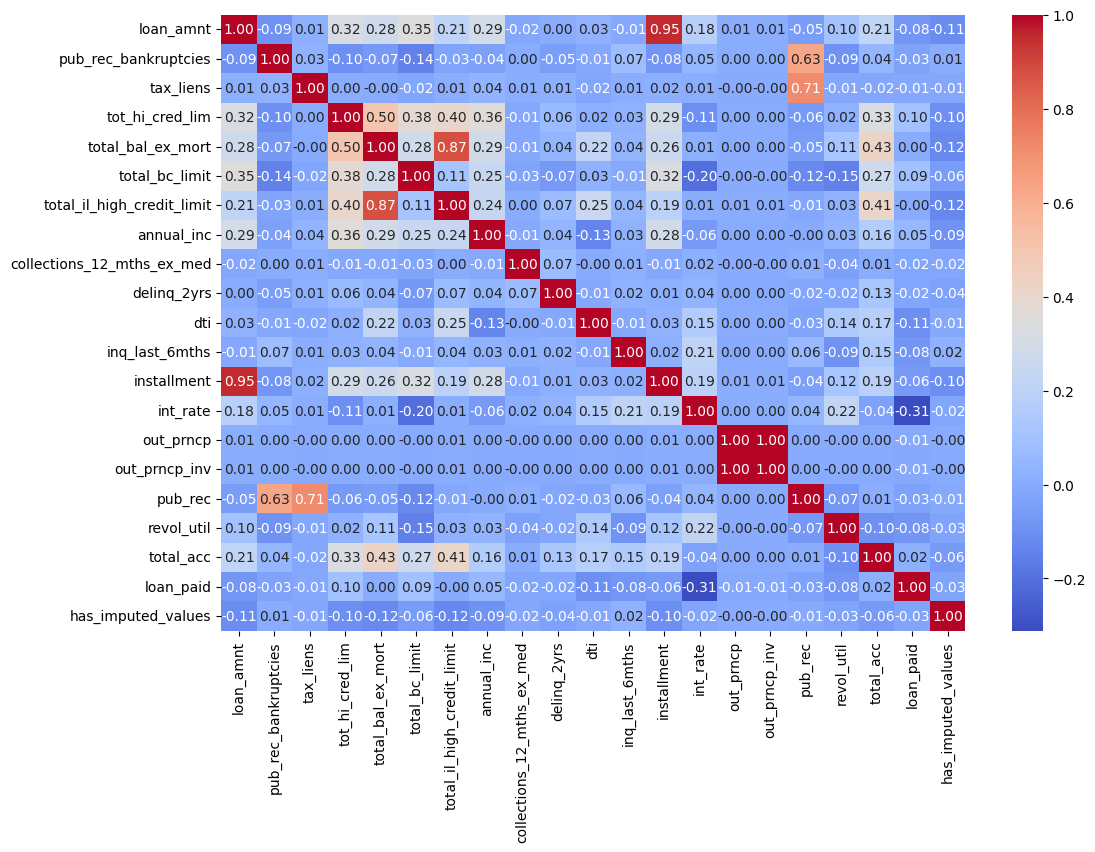

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
#Multicolinearity Analysis
#Create a correlation matrix of numeric variables 
cor_matrix = data.corr(numeric_only=True)
#print(cor_matrix)

#Display a heatmap of the correlations
plt.figure(figsize=(12,8))
sns.heatmap(cor_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()


In [6]:
import pandas as pd
import numpy as np
from datetime import datetime

# Create the four requested features
def create_features(df):
    # 1. Payment to income ratio
    # HAD ISSUE WITH MONTHLY INCOME BEING 0 SO 
# Replace both zeros and NaNs with median value
    median_income = df['monthly_income'].replace(0, np.nan).median()
    df['monthly_income'] = df['monthly_income'].replace(0, median_income)
    
    # Handle annual income
    median_annual_inc = df['annual_inc'].replace(0, np.nan).median()
    df['annual_inc'] = df['annual_inc'].replace(0, median_annual_inc)
    



    # df['payment_to_income_ratio'] = df['installment'] / df['monthly_income']
    
    # 2. Credit age (in years)
    # Convert earliest_cr_line to datetime and calculate age
    df['earliest_cr_line_date'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
    current_date = datetime.now()
    df['credit_age_years'] = ((current_date - df['earliest_cr_line_date']).dt.days / 365.25)
    
    # 3. Payment ratio to loan
    # df['payment_ratio_to_loan'] = df['installment'] / df['loan_amnt']
    
    # 4. Loan amount to income ratio
    df['loan_to_income_ratio'] = df['loan_amnt'] / df['annual_inc']
    
    # 5. Interaction term between fico_score and dti
    # df['fico_dti_interaction'] = df['fico_score'] * df['dti']
    
    # 6. FICO score squared
    df['fico_squared'] = df['fico_score'] ** 2
    
    # Create dummy variables for home ownership
    df['home_ownership_RENT'] = (df['home_ownership'] == 'RENT').astype(int)
    df['home_ownership_MORTGAGE'] = (df['home_ownership'] == 'MORTGAGE').astype(int)
    
    return df

# Apply the function
data = create_features(data)

In [7]:
# def map_grade_to_fico(df):
#     """ Define FICO score ranges for each grade. take the grade and map it to random fico score
#     with the range of the predefined ranges below"""
#     fico_ranges = {
#         'A': (750, 850),
#         'B': (700, 749),
#         'C': (650, 699),
#         'D': (600, 649),
#         'E': (550, 599),
#         'F': (500, 549),
#         'G': (300, 499)
#     }
    
#     # Generate random FICO scores based on grade
#     df['fico_score'] = df['grade'].apply(
#         lambda x: np.random.randint(fico_ranges[x][0], fico_ranges[x][1] + 1)
#     )
    
#     return df

# # Apply the function
# data = map_grade_to_fico(data)

In [9]:
data.isnull().sum()

loan_amnt                     0
verification_status           0
pub_rec_bankruptcies          0
tax_liens                     0
tot_hi_cred_lim               0
total_bal_ex_mort             0
total_bc_limit                0
total_il_high_credit_limit    0
disbursement_method           0
debt_settlement_flag          0
annual_inc                    0
collections_12_mths_ex_med    0
delinq_2yrs                   0
dti                           0
grade                         0
earliest_cr_line              0
emp_length                    0
home_ownership                0
inq_last_6mths                0
installment                   0
int_rate                      0
last_pymnt_d                  0
out_prncp                     0
out_prncp_inv                 0
pub_rec                       0
purpose                       0
revol_util                    0
term                          0
total_acc                     0
loan_paid                     0
has_imputed_values            0
monthly_

In [11]:
boo = data[["home_ownership", "home_ownership_RENT", "home_ownership_MORTGAGE"]]
boo.head(50)

,home_ownership,home_ownership_RENT,home_ownership_MORTGAGE
0,OWN,0,0
1,RENT,1,0
2,RENT,1,0
3,OWN,0,0
4,RENT,1,0
5,RENT,1,0
6,MORTGAGE,0,1
7,RENT,1,0
8,MORTGAGE,0,1
9,RENT,1,0


In [12]:
# Save df to CSV with UTF-8 encoding
data.to_csv('feature_data.csv', index=False, encoding='utf-8')

# Verify the file was created
import os
print(f"File saved to: {os.getcwd()}/feature_data.csv")
print(f"File exists: {os.path.exists('feature_data.csv')}")
print(f"File size: {os.path.getsize('feature_data.csv') / (1024*1024):.2f} MB")

File saved to: c:\CWRU\risk_modeling/feature_data.csv
File exists: True
File size: 60.08 MB


In [51]:
# Check for zeros in monthly_income (denominator)
zero_income = data[data['monthly_income'] == 0]
print(f"Number of records with zero monthly income: {len(zero_income)}")

# Check for zeros in annual_inc
zero_annual_inc = data[data['annual_inc'] == 0]
print(f"Number of records with zero annual income: {len(zero_annual_inc)}")

# Check for zeros in installment (numerator)
zero_installment = data[data['installment'] == 0]
print(f"Number of records with zero installment: {len(zero_installment)}")

# Check for outliers using IQR method
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check for outliers in monthly_income
income_outliers, income_lower, income_upper = detect_outliers(data, 'monthly_income')
print(f"Monthly income outliers: {len(income_outliers)} records")
print(f"Monthly income range: [{income_lower:.2f}, {income_upper:.2f}]")

# Check for outliers in installment
installment_outliers, inst_lower, inst_upper = detect_outliers(data, 'installment')
print(f"Installment outliers: {len(installment_outliers)} records")
print(f"Installment range: [{inst_lower:.2f}, {inst_upper:.2f}]")

# Check for outliers in the ratio itself
ratio_outliers, ratio_lower, ratio_upper = detect_outliers(data, 'payment_to_income_ratio')
print(f"Payment to income ratio outliers: {len(ratio_outliers)} records")
print(f"Payment to income ratio range: [{ratio_lower:.2f}, {ratio_upper:.2f}]")

# Display some extreme values
print("\nTop 5 highest payment_to_income_ratio values:")
print(data.nlargest(5, 'payment_to_income_ratio')[['monthly_income', 'installment', 'payment_to_income_ratio']])

Number of records with zero monthly income: 0
Number of records with zero annual income: 0
Number of records with zero installment: 0
Monthly income outliers: 9339 records
Monthly income range: [-1750.00, 12916.67]
Installment outliers: 6345 records
Installment range: [-236.85, 1086.38]
Payment to income ratio outliers: 2271 records
Payment to income ratio range: [-0.04, 0.20]

Top 5 highest payment_to_income_ratio values:
        monthly_income  installment  payment_to_income_ratio
186788        0.083333       440.51                5286.1200
108852        0.166667       490.45                2942.7000
53554         0.083333        79.11                 949.3200
17870         1.666667       155.19                  93.1140
197820        8.333333       264.94                  31.7928
